#Agenda:
- kaggle Dataset Mnist dataset
- Train on ANN
- improve

Steps to use GPU:

* Write device Agnostic Code
* Move Model to GPU
* Modify the Training loop by moving Data to GPU
* Moving the Data to GPU in Evaluation Loop

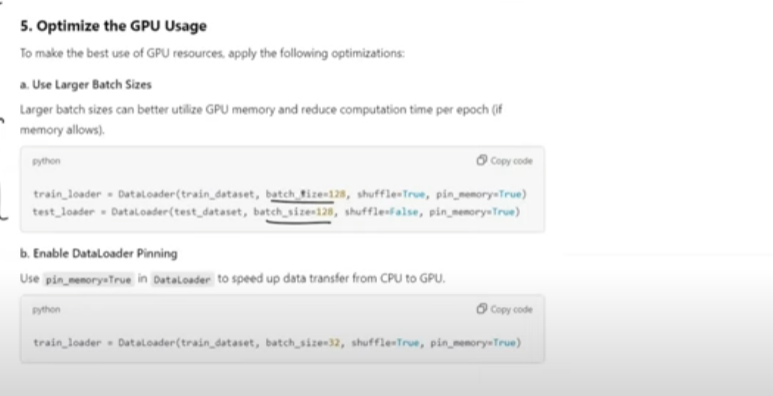

In [39]:
#importing some necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset,DataLoader

In [40]:
#device Agnostic code
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [41]:
#random seed for reproducibility
torch.manual_seed(42)

In [42]:
!kaggle datasets download -d zalando-research/fashionmnist

Dataset URL: https://www.kaggle.com/datasets/zalando-research/fashionmnist
License(s): other
fashionmnist.zip: Skipping, found more recently modified local copy (use --force to force download)


In [43]:
!unzip fashionmnist.zip

Archive:  fashionmnist.zip
replace fashion-mnist_test.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace fashion-mnist_train.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: fashion-mnist_train.csv  
replace t10k-images-idx3-ubyte? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [44]:
df=pd.read_csv('/content/fashion-mnist_train.csv')

In [45]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


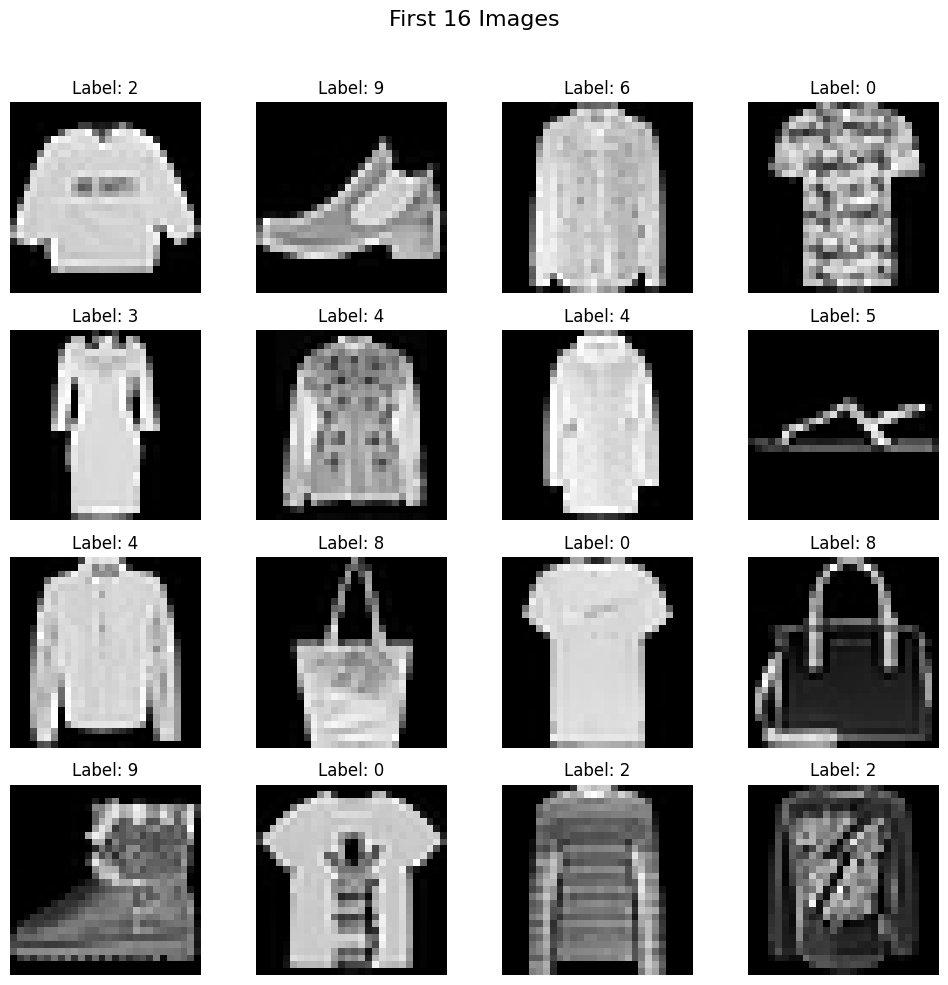

In [46]:
# Create a 4x4 grid of subplots
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images", fontsize=16)  # Set a title for the whole figure

# Loop through the first 16 images and plot them
for i, ax in enumerate(axes.flat):  # Iterate over all 16 subplot axes
    img = df.iloc[i, 1:].values.reshape(28, 28)  # Extract pixel values and reshape to 28x28
    ax.imshow(img, cmap='gray')  # Display the image in grayscale
    ax.axis('off')  # Remove the axis for a cleaner look
    ax.set_title(f"Label: {df.iloc[i, 0]}")  # Display the label

# Adjust layout to fit the title properly
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()  # Display the plot

In [47]:
#generate x and y
x=df.iloc[:,1:].values
y=df.iloc[:,0].values

In [48]:
x_train,x_test,y_train,y_test=train_test_split(
    x,y,
    test_size=0.2,
    random_state=42
)

In [49]:
#scaling our dataset
x_train=x_train/255.0
x_test=x_test/255.0

In [50]:
x_train

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.00392157, 0.        ,
        0.        ]])

In [51]:
x_train.shape

(48000, 784)

In [52]:
#custom dataset
class CustomDataset(Dataset):

  def __init__(self,feature,labels):

    self.feature=torch.tensor(feature,dtype=torch.float32)
    self.labels=torch.tensor(labels,dtype=torch.long)

  def __len__(self):
    return len(self.feature)

  def __getitem__(self,index):

    return self.feature[index],self.labels[index]

In [53]:
train_dataset=CustomDataset(x_train,y_train)

In [54]:
test_dataset=CustomDataset(x_test,y_test)

In [55]:
len(train_dataset)

48000

In [56]:
len(test_dataset)

12000

In [57]:
train_loader=DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

In [58]:
test_loader=DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [59]:
#create ANN Model

class MyNN(nn.Module):

  def __init__(self,input_size):
    super().__init__()
    self.network=nn.Sequential(
        nn.Linear(in_features=input_size,out_features=128),
        nn.BatchNorm1d(num_features=128),
        nn.ReLU(),
        nn.Dropout(p=0.3), # to reduce overfit
        nn.Linear(in_features=128,out_features=64),
        nn.BatchNorm1d(num_features=64),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(64,10)
    )

  def forward(self,x):
    return self.network(x)

In [67]:
#set epochs nad learning rate
epochs=100
lr=0.01

In [68]:
#instance of model
model=MyNN(x_train.shape[1])
model=model.to(device)
#loss functions
loss=nn.CrossEntropyLoss()

#optimizer
optimizer=optim.SGD(
    params=model.parameters(),
    lr=lr,
    weight_decay=1e-4 #L2 Regularizaton
)

In [69]:
#Training loop
for epoch in range(epochs):
  each_epoch_loss=0 #to calcluate loss of each epoch
  for batch_feature,batch_label in train_loader:
    #moving data to gpu
    batch_feature,batch_label=batch_feature.to(device),batch_label.to(device)
    #forward pass
    y_pred=model(batch_feature)
    #calculate loss
    train_loss=loss(y_pred,batch_label)
    #backpropagation
    optimizer.zero_grad()
    train_loss.backward()
    #update parameters
    optimizer.step()

    each_epoch_loss+=train_loss.item()
  avg_loss=each_epoch_loss/len(train_loader)
  print(f"Epoch: {epoch} | Loss: {avg_loss}")


Epoch: 0 | Loss: 0.8065808936754862
Epoch: 1 | Loss: 0.5597448201775551
Epoch: 2 | Loss: 0.5094892715712388
Epoch: 3 | Loss: 0.4810105194548766
Epoch: 4 | Loss: 0.4612524435023467
Epoch: 5 | Loss: 0.44269148775935174
Epoch: 6 | Loss: 0.4315331518352032
Epoch: 7 | Loss: 0.4204880580653747
Epoch: 8 | Loss: 0.4116639976402124
Epoch: 9 | Loss: 0.40149565060436726
Epoch: 10 | Loss: 0.39281141313910484
Epoch: 11 | Loss: 0.38667456892629465
Epoch: 12 | Loss: 0.3760320199082295
Epoch: 13 | Loss: 0.37434604674081007
Epoch: 14 | Loss: 0.3695418321887652
Epoch: 15 | Loss: 0.3636629396279653
Epoch: 16 | Loss: 0.3581403512532512
Epoch: 17 | Loss: 0.35589148640135926
Epoch: 18 | Loss: 0.3501646497497956
Epoch: 19 | Loss: 0.3445249264985323
Epoch: 20 | Loss: 0.34133856614430746
Epoch: 21 | Loss: 0.33866971828540166
Epoch: 22 | Loss: 0.33425082622965174
Epoch: 23 | Loss: 0.3326152075976133
Epoch: 24 | Loss: 0.32751335051655767
Epoch: 25 | Loss: 0.3304801698798935
Epoch: 26 | Loss: 0.3199899627616008
E

In [70]:
#Model Evaluation
model.eval()

MyNN(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [71]:
total=0
correct=0

with torch.no_grad():
  for batch_feature,batch_label in test_loader:
    batch_feature,batch_label=batch_feature.to(device),batch_label.to(device)
    y_pred=model(batch_feature)
    _,predict=torch.max(y_pred,1)
    total+=batch_label.shape[0]
    correct+=(predict==batch_label).sum().item()
print(f"{(correct/total)*100}%")


89.58333333333334%


In [72]:
#Evaluation for training data
total=0
correct=0

with torch.no_grad():
  for batch_feature,batch_label in train_loader:
    batch_feature,batch_label=batch_feature.to(device),batch_label.to(device)
    y_pred=model(batch_feature)
    _,predict=torch.max(y_pred,1)
    total+=batch_label.shape[0]
    correct+=(predict==batch_label).sum().item()
print(f"{(correct/total)*100}%")

95.74375%


if there is a huge gap between trianing data and test data accuracy then the model could be Overfit and underfit


**solutions to Reduce Overfit:**

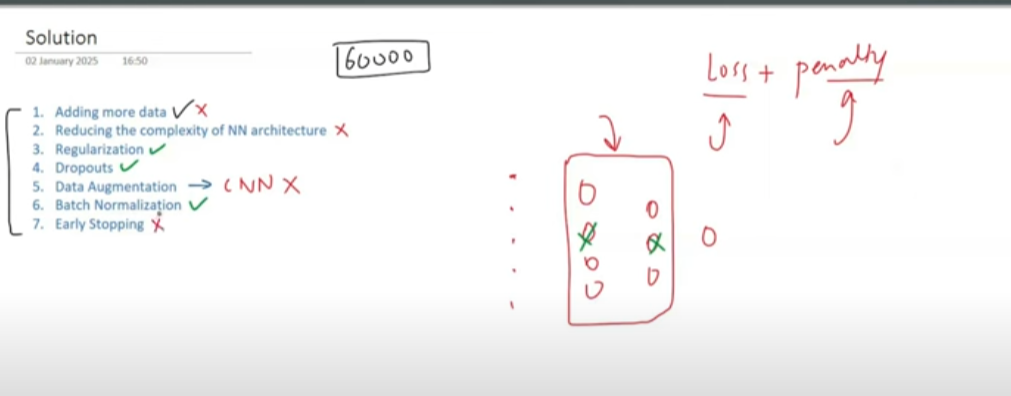

we are going to use three techniques here to overcome overfit our model:
* Droupout
* Regularization
* Batch Normalization

#Droupout:

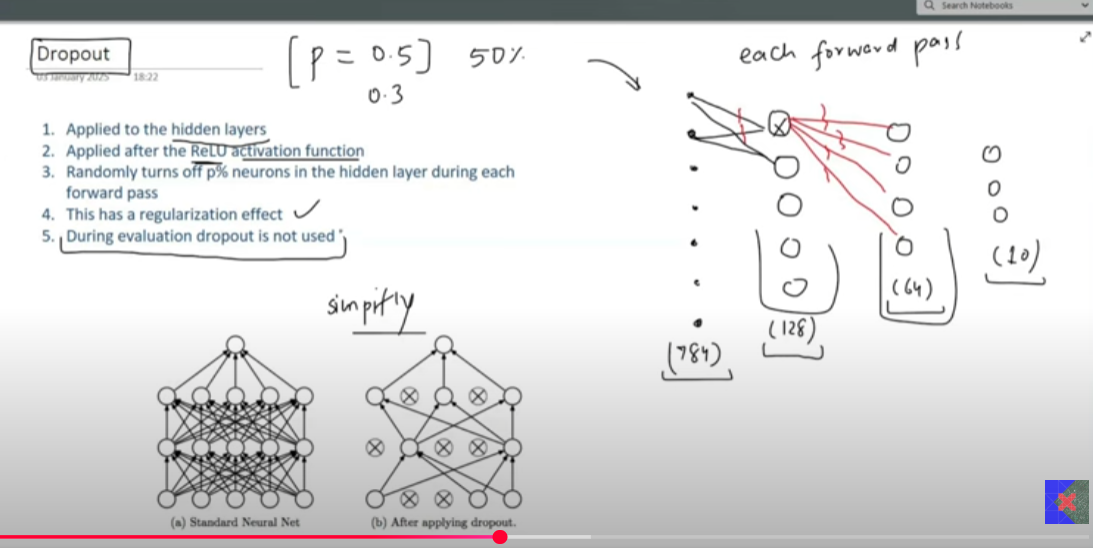

**Batch Normalization**:

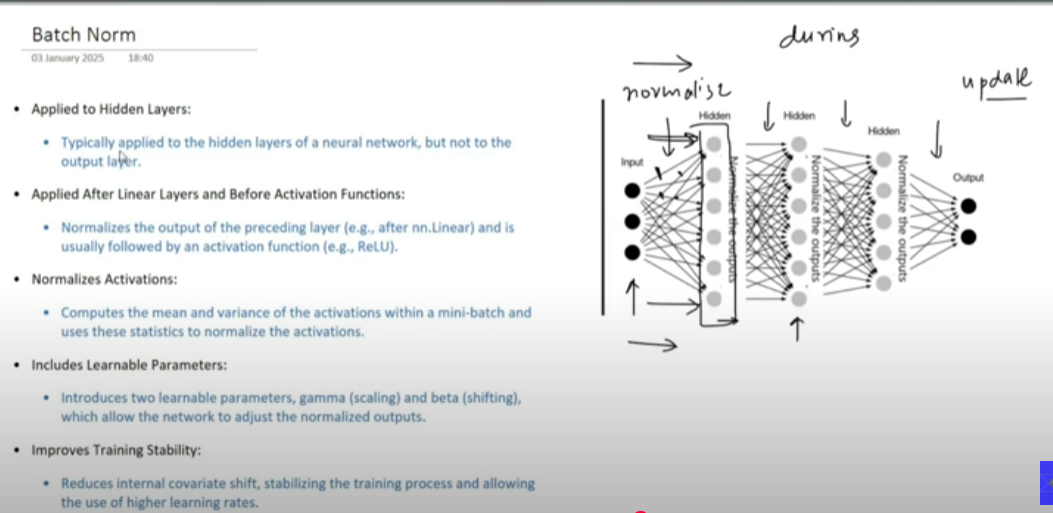

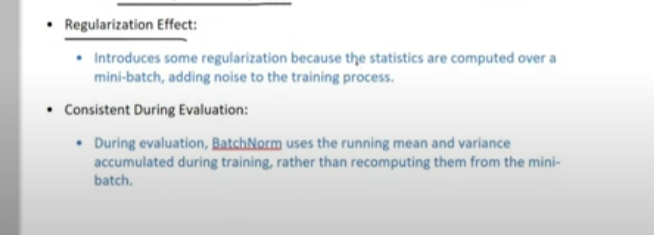

**Regularization**:

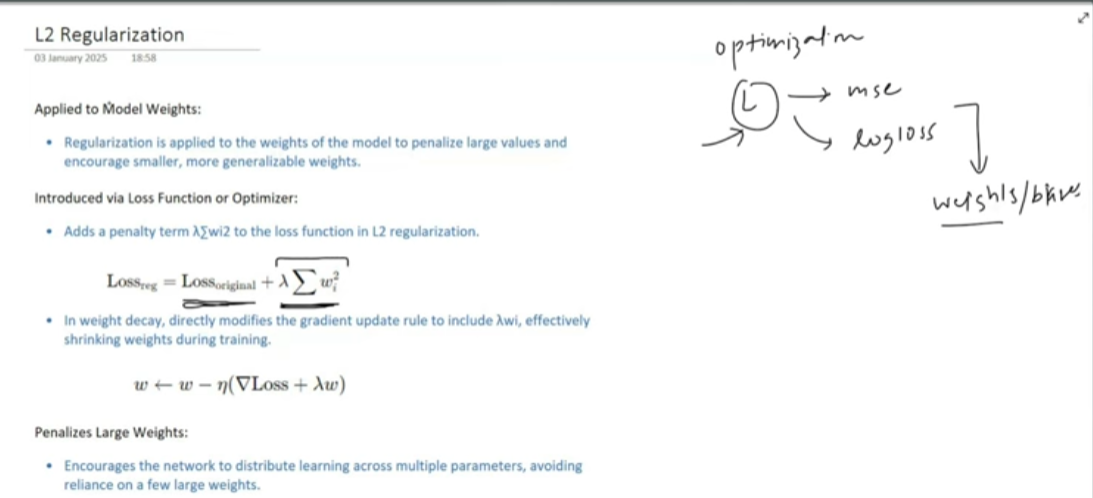

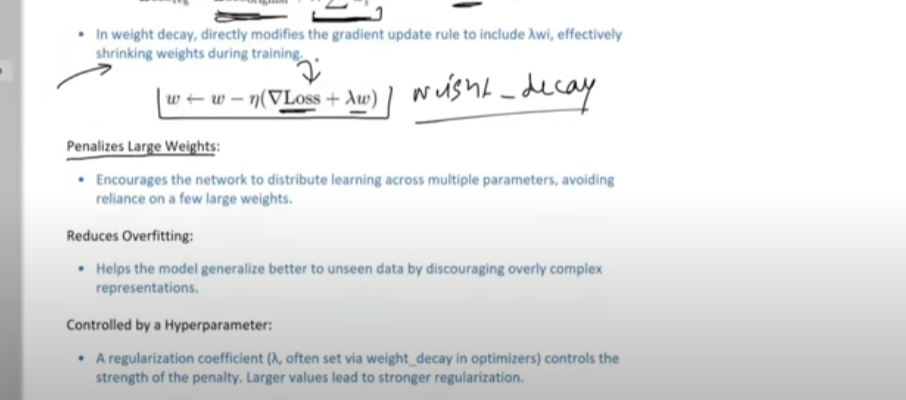

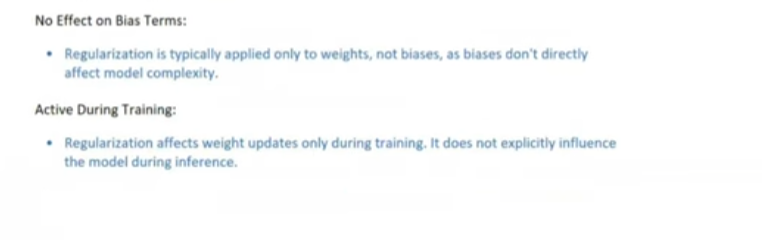